In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# clone SimMIM
!git clone https://github.com/microsoft/SimMIM.git
%cd /content/SimMIM

!pip install -q timm==0.4.12 yacs termcolor scipy pyyaml

Cloning into 'SimMIM'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 65 (delta 17), reused 9 (delta 9), pack-reused 32 (from 1)
Receiving objects: 100% (65/65), 289.62 KiB | 11.14 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/SimMIM
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 11.3 MB/s eta 0:00:00


In [12]:
from torchvision.datasets import CIFAR10
from pathlib import Path

root = Path("/content/cifar10_simmim_subset/train")
root.mkdir(parents=True, exist_ok=True)

dataset = CIFAR10(root="/content/cifar10_data", train=True, download=True)

max_per_class = 200
class_counts = {i: 0 for i in range(10)}

for img, label in dataset:
    if class_counts[label] >= max_per_class:
        continue

    class_dir = root / str(label)
    class_dir.mkdir(parents=True, exist_ok=True)

    img.save(class_dir / f"{class_counts[label]:04d}.png")
    class_counts[label] += 1

    if all(v >= max_per_class for v in class_counts.values()):
        break

print(class_counts)
print("Saved to:", root)

100%|██████████| 170M/170M [01:31<00:00, 1.86MB/s]


{0: 200, 1: 200, 2: 200, 3: 200, 4: 200, 5: 200, 6: 200, 7: 200, 8: 200, 9: 200}
Saved to: /content/cifar10_simmim_subset/train


In [13]:
!find /content/cifar10_simmim_subset/train -type f | wc -l

2000


In [29]:
import os
import sys
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

In [30]:
SIMMIM_ROOT = "/content/SimMIM"
if SIMMIM_ROOT not in sys.path:
    sys.path.insert(0, SIMMIM_ROOT)
from config import get_config
from models import build_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_BASE_DIR = Path("/content/drive/MyDrive/CS543/Finalproj/simmim_pretrain")
config_file = os.path.join(SIMMIM_ROOT, "configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml")

In [31]:
class DummyArgs:
    def __init__(self, cfg_path):
        self.cfg = cfg_path
        self.opts = []
        self.batch_size = None
        self.data_path = None
        self.resume = None
        self.output = None
        self.tag = None
        self.amp_opt_level = None
        self.local_rank = 0

config = get_config(DummyArgs(config_file))
config.defrost()
config.DATA.IMG_SIZE = 192
config.freeze()

print("Initializing Swin-Base SimMIM architecture...")
model = build_model(config).to(device)

=> merge config from /content/SimMIM/configs/swin_base__100ep/simmim_pretrain__swin_base__img192_window6__100ep.yaml
Initializing Swin-Base SimMIM architecture...


In [37]:
transform = T.Compose([T.Resize((192, 192)), T.ToTensor()])
img_path = "/content/cifar10_simmim_subset/train/0/0057.png"
raw_img = Image.open(img_path).convert('RGB')
img_tensor = transform(raw_img).unsqueeze(0).to(device)

Starting batch checkpoint inference and image reconstruction...


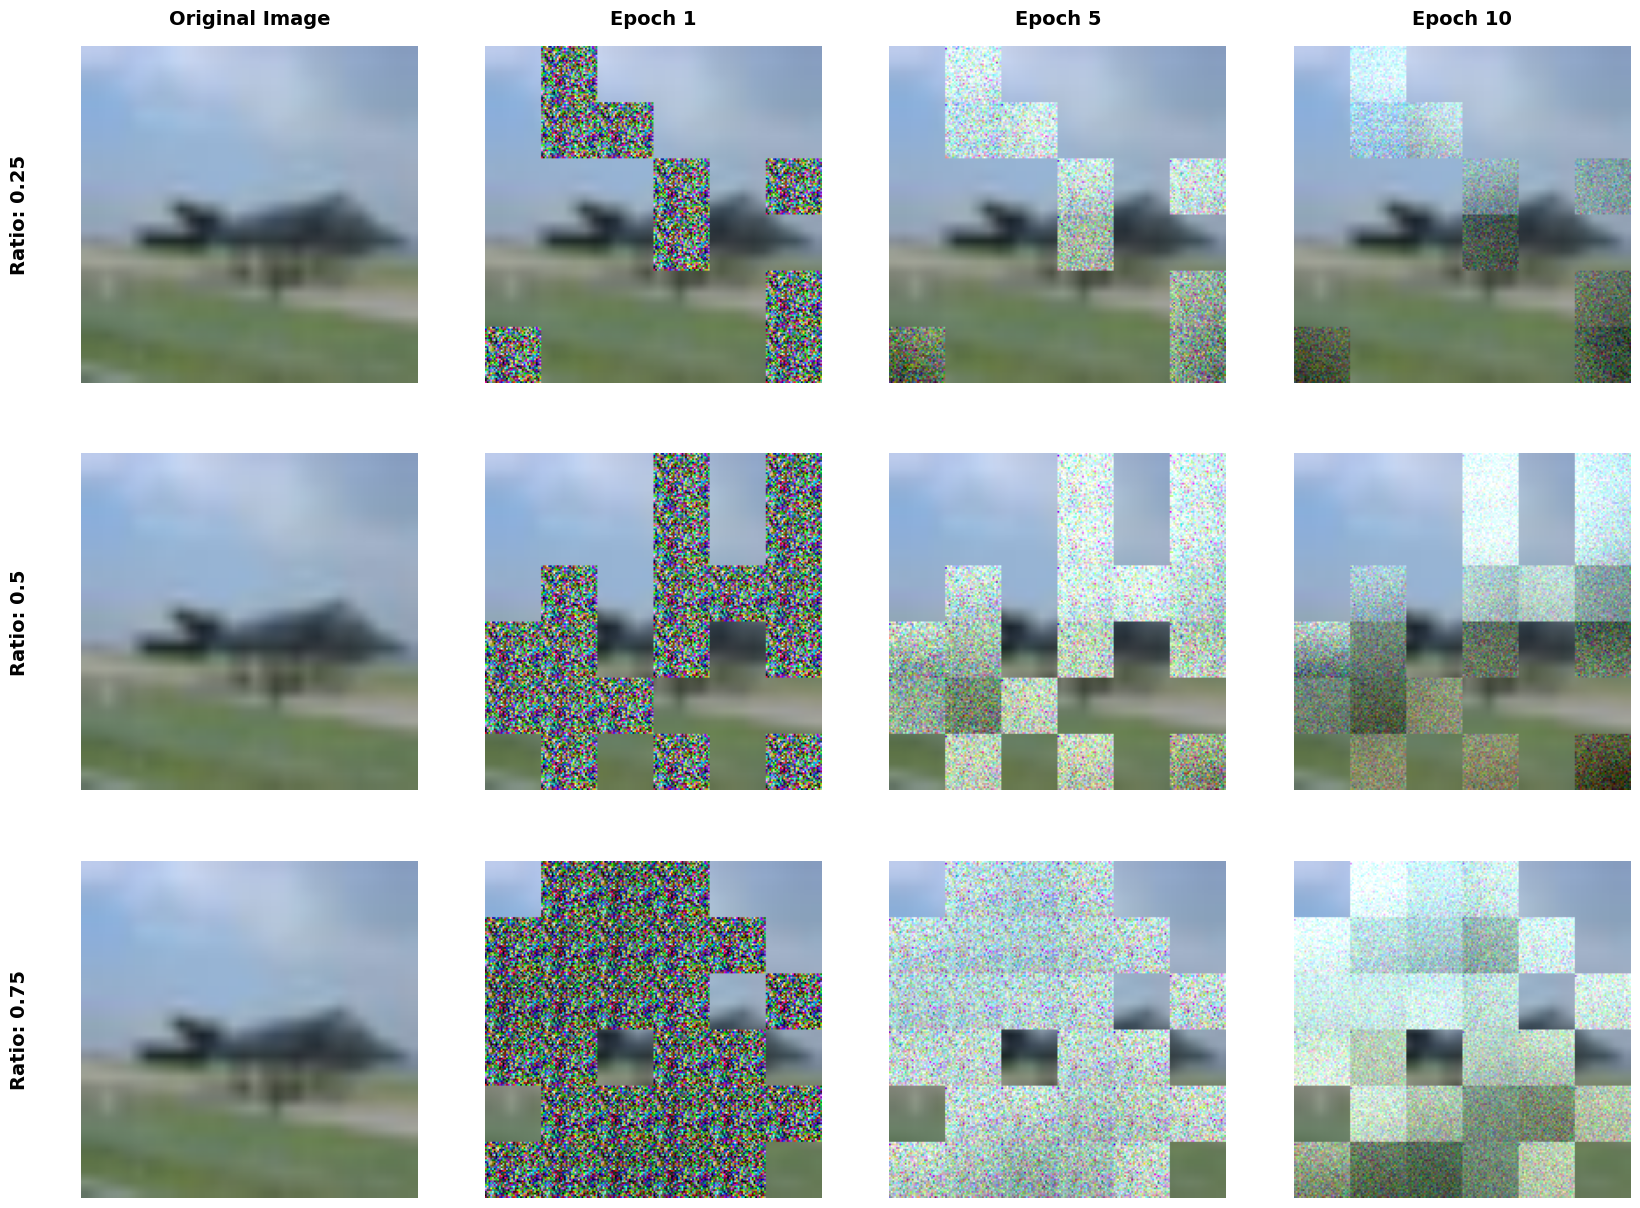

In [49]:
def generate_simmim_mask(img_size=192, patch_size=4, mask_patch_size=32, mask_ratio=0.6) -> torch.Tensor:
    mask_tokens = img_size // mask_patch_size   # 6
    scale = mask_patch_size // patch_size       # 8
    num_mask = int(mask_tokens * mask_tokens * mask_ratio)
    mask = torch.zeros(mask_tokens, mask_tokens)
    mask.view(-1)[torch.randperm(mask_tokens * mask_tokens)[:num_mask]] = 1
    return mask.repeat_interleave(scale, dim=0).repeat_interleave(scale, dim=1)

def to_numpy_img(tensor):
    return np.clip(tensor.squeeze(0).cpu().permute(1, 2, 0).numpy(), 0, 1)

# Ablation experiment grid setup
ratios = [0.25, 0.50, 0.75]
epochs_list = [1, 5, 10]

# Create a 3x4 layout subplot canvas
fig, axes = plt.subplots(len(ratios), len(epochs_list) + 1, figsize=(20, 15))

print("Starting batch checkpoint inference and image reconstruction...")

for r_idx, ratio in enumerate(ratios):
    # Generate a fixed mask configuration for the current row
    mask_tensor = generate_simmim_mask(img_size=192, mask_ratio=ratio).unsqueeze(0).to(device)
    full_mask = mask_tensor.repeat_interleave(4, dim=1).repeat_interleave(4, dim=2).unsqueeze(1)

    # Column 1: Render the original image
    # NOTE: If you prefer to display the masked input patch version here,
    # change `img_tensor` to `img_tensor * (1 - full_mask)` inside the imshow function.
    ax_orig = axes[r_idx, 0]
    ax_orig.imshow(to_numpy_img(img_tensor))
    ax_orig.axis('off')

    # Add row labels for mask ratios on the left margin
    ax_orig.text(-30, 96, f"Ratio: {ratio}", va='center', ha='right', fontsize=14, fontweight='bold', rotation=90)
    if r_idx == 0:
        ax_orig.set_title("Original Image", fontsize=14, fontweight='bold', pad=15)

    # Loop through Epochs 1, 5, 10 checkpoints and perform forward passes
    for e_idx, epochs in enumerate(epochs_list):
        col_idx = e_idx + 1 # Shifting index by 1 to skip the original image column
        ax_curr = axes[r_idx, col_idx]

        # Dynamically string-match your Google Drive checkpoint directory structure
        tag = f"mask{int(ratio*100):03d}_epoch{epochs}"
        ckpt_path = OUTPUT_BASE_DIR / tag / f"ckpt_epoch_{epochs-1}.pth"

        if not ckpt_path.exists():
            ax_curr.text(0.5, 0.5, f"Missing Weight\n{tag}", ha='center', va='center', color='red', fontsize=12)
            ax_curr.axis('off')
            continue

        # Hot-swap the model parameters safely using safe globals load bypass
        checkpoint = torch.load(str(ckpt_path), map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model'] if 'model' in checkpoint else checkpoint, strict=True)
        model.eval()

        # Core feature extraction bypass to avoid loss logging overhead
        with torch.no_grad():
            if hasattr(model, 'encoder'):
                x = model.encoder(img_tensor, mask_tensor)
                pred = model.decoder(x)
            else:
                output = model(img_tensor, mask_tensor)
                pred = output if not isinstance(output, tuple) else output[1]

        try:
            pred_img = model.patch_to_img(pred)
        except:
            pred_img = pred

        # Composite the mask: preserve unmasked original pixels and inject decoder output tokens
        combined_img = img_tensor * (1 - full_mask) + pred_img * full_mask

        # Plotting the reconstruction result
        ax_curr.imshow(to_numpy_img(combined_img))
        ax_curr.axis('off')
        if r_idx == 0:
            ax_curr.set_title(f"Epoch {epochs}", fontsize=14, fontweight='bold', pad=15)

This 12-grid ablation matrix proves that our SimMIM model is training correctly because as execution moves from left to right, the model successfully suppresses the chaotic, uncoordinated pixel noise seen at Epoch 1 and shifts toward safe, low-frequency background color-matching by Epoch 5, eventually evolving into early structural alignment and rough macro-shape capturing by Epoch 10. Simultaneously, reading the matrix from top to bottom shows that task difficulty directly scales with the masking ratio, where a 0.25 ratio yields clean and almost seamless patch blending due to abundant surrounding contextual hints, whereas the highly starved 0.75 ratio leaves the local attention windows of the Swin Transformer architecture completely isolated, resulting in faded, over-smoothed, and structurally lost reconstructions at Epoch 10.